# Bike Buyers Data Analysis



## Project Goal
Analyze customer data to understand factors that influence bike purchasing decisions.

#Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score



In [ ]:
from google.colab import files
file = files.upload()


Saving bike_buyers.csv to bike_buyers.csv


#Data Cleaning

In [ ]:
Bikes = pd.read_csv("bike_buyers.csv")
Bikes.head(10)

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
5,13507,Married,Female,10000.0,2.0,Partial College,Manual,Yes,0.0,1-2 Miles,Europe,50.0,No
6,27974,Single,Male,160000.0,2.0,High School,Management,NaN,4.0,0-1 Miles,Pacific,33.0,Yes
7,19364,Married,Male,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,43.0,Yes
8,22155,NaN,Male,20000.0,2.0,Partial High School,Clerical,Yes,2.0,5-10 Miles,Pacific,58.0,No
9,19280,Married,Male,NaN,2.0,Partial College,Manual,Yes,1.0,0-1 Miles,Europe,NaN,Yes


In [ ]:
Bikes.describe(include = "all")

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
count,1000.000000,993,989,994.000000,992.000000,1000,1000,996,991.000000,1000,1000,992.000000,1000
unique,NaN,2,2,NaN,NaN,5,5,2,NaN,5,3,NaN,2
top,NaN,Married,Male,NaN,NaN,Bachelors,Professional,Yes,NaN,0-1 Miles,North America,NaN,No
freq,NaN,535,500,NaN,NaN,306,276,682,NaN,366,508,NaN,519
mean,19965.992000,NaN,NaN,56267.605634,1.910282,NaN,NaN,NaN,1.455096,NaN,NaN,44.181452,NaN
std,5347.333948,NaN,NaN,31067.817462,1.626910,NaN,NaN,NaN,1.121755,NaN,NaN,11.362007,NaN
min,11000.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,25.000000,NaN
25%,15290.750000,NaN,NaN,30000.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,35.000000,NaN
50%,19744.000000,NaN,NaN,60000.000000,2.000000,NaN,NaN,NaN,1.000000,NaN,NaN,43.000000,NaN
75%,24470.750000,NaN,NaN,70000.000000,3.000000,NaN,NaN,NaN,2.000000,NaN,NaN,52.000000,NaN


In [ ]:
Bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    993 non-null    object 
 2   Gender            989 non-null    object 
 3   Income            994 non-null    float64
 4   Children          992 non-null    float64
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home Owner        996 non-null    object 
 8   Cars              991 non-null    float64
 9   Commute Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               992 non-null    float64
 12  Purchased Bike    1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 101.7+ KB


### Based on this initial segmentation, we already know that **there** is missing data in the table.

#Analysis

## We will insert the file into a pandas data frame:
Split the data to:

X: the feature matrix

y: the label vector

In [ ]:
#your code here:
X_Bikes = Bikes.drop(columns=['Purchased Bike'])
Y_Bikes = Bikes['Purchased Bike']
X_Bikes.head()
#ChatGPT is used

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0


In [ ]:
Y_Bikes.head()

,Purchased Bike
0,No
1,No
2,No
3,Yes
4,Yes


#Visualization

###we create and print a plot that demonstartes the frequency of each class of the label variable (Y). In addition, we print the count of each of the classes  of the label variable (Y).

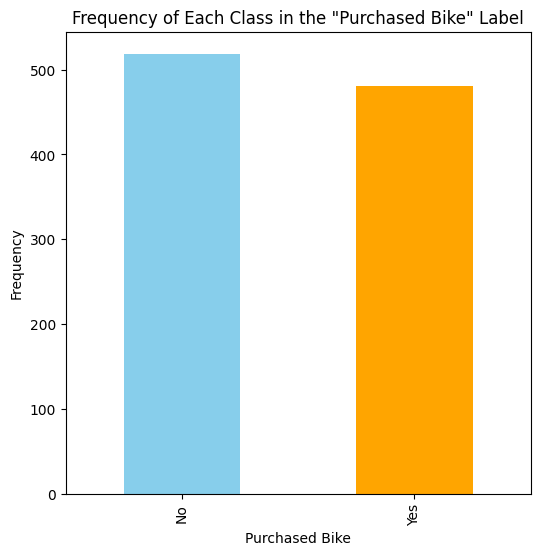

In [ ]:
#your code here:
plt.figure(figsize=(6, 6))
Y_Bikes.value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Frequency of Each Class in the "Purchased Bike" Label')
plt.xlabel('Purchased Bike')
plt.ylabel('Frequency')
plt.show()
#ChatGPT is used

### According to this initial graph, we already know that there are slightly more than 50% of people in the data who did not buy a bicycle, and if so, we can say that there are more people who did not buy a bicycle than people who did buy a bicycle.

### We see from the graph that the data is almost equal in percentage between those who have bicycles and those who do not, so we believe that the reasons that would make us want to balance the data are very low and most of the things we want to investigate will not be affected if we do not balance the data because they are quite balanced naturally - and therefore we decided that we **do not** want to balance our original data.

This dataset exhibits a relatively balanced class distribution. Nevertheless, for demonstration purposes, we will implement and explain two common re-sampling techniques: one under-sampling method and one over-sampling method. We will then discuss the underlying logic of each approach.

In [ ]:
# Separate the dataset into the minority and majority classes based on the 'Purchased Bike' label
Bikes_majority = Bikes[Bikes['Purchased Bike'] == 'No']
Bikes_minority = Bikes[Bikes['Purchased Bike'] == 'Yes']

# Print initial class counts for reference
print(f"Initial class counts:\n{Bikes['Purchased Bike'].value_counts()}")

# 1. Over-Sampling using Random Over-Sampling
Bikes_minority_oversampled = resample(Bikes_minority,
                                   replace=True,     # Sample with replacement
                                   n_samples=len(Bikes_majority),  # Match the number in majority class
                                   random_state=42)  # For reproducibility

# Combine the majority class with the upsampled minority class
Bikes_oversampled = pd.concat([Bikes_majority, Bikes_minority_oversampled])

# 2. Under-Sampling using Random Under-Sampling
Bikes_majority_undersampled = resample(Bikes_majority,
                                    replace=False,    # Sample without replacement
                                    n_samples=len(Bikes_minority),  # Match the number in minority class
                                    random_state=42)  # For reproducibility

# Combine the minority class with the downsampled majority class
Bikes_undersampled = pd.concat([Bikes_majority_undersampled, Bikes_minority])

# Print new class counts for reference
print(f"\nClass counts after Over-Sampling:\n{Bikes_oversampled['Purchased Bike'].value_counts()}")
print(f"\nClass counts after Under-Sampling:\n{Bikes_undersampled['Purchased Bike'].value_counts()}")

Initial class counts:
Purchased Bike
No     519
Yes    481
Name: count, dtype: int64

Class counts after Over-Sampling:
Purchased Bike
No     519
Yes    519
Name: count, dtype: int64

Class counts after Under-Sampling:
Purchased Bike
No     481
Yes    481
Name: count, dtype: int64


# לא ראינו את זה עד עכשיו, אבל למעשה עשינו את מה שמתבקש פה כבר למעלה בסעיפים קודמים (העתקנו שוב את הקוד פה - הפעם לא כהערה)
# רק נחדד טיפה יותר את הנקודה למה אנחנו לא צריכים לאזן את הנתונים שלנו:
# 1. כי הם כמעט לגמרי מאוזנים באופן טבעי
# 2. כי מספר הדברים שנרצה לעשות ולמדוד שיושפע מכך שלא עשינו איזון קטן בעינינו מהחיסרון שיש באיזון שהוא בעיוות הדאטא או בהשמדת חלק מהדאטא בשני המקרים האפשריים

#4. Check for missing values:

In [ ]:
#your code here:
Bikes_oversampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1038 entries, 0 to 759
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1038 non-null   int64  
 1   Marital Status    1023 non-null   object 
 2   Gender            1029 non-null   object 
 3   Income            1028 non-null   float64
 4   Children          1032 non-null   float64
 5   Education         1038 non-null   object 
 6   Occupation        1038 non-null   object 
 7   Home Owner        1033 non-null   object 
 8   Cars              1028 non-null   float64
 9   Commute Distance  1038 non-null   object 
 10  Region            1038 non-null   object 
 11  Age               1027 non-null   float64
 12  Purchased Bike    1038 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 113.5+ KB


In [ ]:
missing_values_count = Bikes_oversampled.isnull().sum()
missing_values_count
#ChatGPT is used


,0
ID,0
Marital Status,15
Gender,9
Income,10
Children,6
Education,0
Occupation,0
Home Owner,5
Cars,10
Commute Distance,0


# מהבדיקות שעשינו נראה כי יש ערכים חסרים בדאטא (בגיל ובעוד כמה קטגוריות) ועל כן אנו לא מוציאים ממצב הערה את הקוד פה למטה, אלא ישירות עוברים אל סעיף 5

If there are no missing values in your data, follow the next steps:
1. uncomment the following function by:

  a. selecting all the code in the chunk

  b. pressing "ctrl"+"/" to uncomment all lines
2. assign the missing values-containing data to a new variable name (see example below).

Say my dataset features is named X.

Than the use of the function would be:


```
X_missing=add_missing_values(X)
 ```






In [ ]:
# def add_missing_values(X_full):
#     import numpy as np
#     Col_names=X_full.columns
#     X_full=X_full.to_numpy()
#     rng = np.random.RandomState(4)
#     n_samples, n_features = X_full.shape

#     # Add missing values in 75% of the lines
#     missing_rate = 0.75
#     n_missing_samples = int(n_samples * missing_rate)

#     missing_samples = np.zeros(n_samples, dtype=bool)
#     missing_samples[:n_missing_samples] = True

#     rng.shuffle(missing_samples)
#     missing_features = rng.randint(0, n_features, n_missing_samples)
#     X_missing = X_full.copy()
#     X_missing[missing_samples, missing_features] = np.nan
#     X_missing=pd.DataFrame(X_missing)
#     X_missing.columns=Col_names
#     return X_missing
# X_missing


In [ ]:
#your code here, if there are no missing values:



#5. Impute the missing values using three different methods and assign the imputed output datasets into variables:

In [ ]:
#your code here:

# Identify numerical and categorical columns
num_cols = Bikes_oversampled.select_dtypes(include=['number']).columns
cat_cols = Bikes_oversampled.select_dtypes(include=['object']).columns

# Create imputers
mean_imputer = SimpleImputer()
most_frequent_imputer = SimpleImputer(strategy='most_frequent')
iterative_imputer = IterativeImputer()

# Create copies of the original DataFrame for imputation
Bikes_mean_imputed = Bikes_oversampled.copy()
Bikes_most_frequent_imputed = Bikes_oversampled.copy()
Bikes_iterative_imputed = Bikes_oversampled.copy()

#1 - simple imputer by mean (defualt)
Bikes_mean_imputed[num_cols] = mean_imputer.fit_transform(Bikes_oversampled[num_cols])
Bikes_mean_imputed[cat_cols] = most_frequent_imputer.fit_transform(Bikes_oversampled[cat_cols])

#2 - simple imputer by most_frequent
Bikes_most_frequent_imputed[num_cols] = most_frequent_imputer.fit_transform(Bikes_oversampled[num_cols])
Bikes_most_frequent_imputed[cat_cols] = most_frequent_imputer.fit_transform(Bikes_oversampled[cat_cols])

#3 - iterative imputer (was not learn in class)
Bikes_iterative_imputed[num_cols] = iterative_imputer.fit_transform(Bikes_oversampled[num_cols])
Bikes_iterative_imputed[cat_cols] = most_frequent_imputer.fit_transform(Bikes_oversampled[cat_cols])

#ChatGPT is used

# גם באיטרטיב וגם בממוצע השתמשנו בהכי שכיח על מנת להשלים את הערכים הקטגורליים כי אי אפשר להשלים אותם על ידי ממוצע או איטרציות

In [ ]:
Bikes_mean_imputed.info(), Bikes_most_frequent_imputed.info(), Bikes_iterative_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1038 entries, 0 to 759
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1038 non-null   float64
 1   Marital Status    1038 non-null   object 
 2   Gender            1038 non-null   object 
 3   Income            1038 non-null   float64
 4   Children          1038 non-null   float64
 5   Education         1038 non-null   object 
 6   Occupation        1038 non-null   object 
 7   Home Owner        1038 non-null   object 
 8   Cars              1038 non-null   float64
 9   Commute Distance  1038 non-null   object 
 10  Region            1038 non-null   object 
 11  Age               1038 non-null   float64
 12  Purchased Bike    1038 non-null   object 
dtypes: float64(5), object(8)
memory usage: 113.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1038 entries, 0 to 759
Data columns (total 13 columns):
 #   Column            Non-Null Count  

(None, None, None)

#6. Preprocessing (for the three new imputed datasets):
standardize or normalize the data


In [ ]:
#your code here:

# Initialize the MinMaxScaler for normalization
minmax_scaler = MinMaxScaler()

# Create copies of the imputed DataFrames for normalization
Bikes_mean_normalized = Bikes_mean_imputed.copy()
Bikes_most_frequent_normalized = Bikes_most_frequent_imputed.copy()
Bikes_iterative_normalized = Bikes_iterative_imputed.copy()

# List of new DataFrames for normalized versions
normalized_dfs = [Bikes_mean_normalized, Bikes_most_frequent_normalized, Bikes_iterative_normalized]

# Loop through each new DataFrame for normalization
for df in normalized_dfs:
    # Normalize numerical columns and replace original ones
    normalized_values = minmax_scaler.fit_transform(df[num_cols])
    df[num_cols] = normalized_values

# Since the DataFrames are copies, the original imputed DataFrames remain unchanged.

#ChatGPT is used

In [ ]:
Bikes_mean_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1038 entries, 0 to 759
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1038 non-null   float64
 1   Marital Status    1038 non-null   object 
 2   Gender            1038 non-null   object 
 3   Income            1038 non-null   float64
 4   Children          1038 non-null   float64
 5   Education         1038 non-null   object 
 6   Occupation        1038 non-null   object 
 7   Home Owner        1038 non-null   object 
 8   Cars              1038 non-null   float64
 9   Commute Distance  1038 non-null   object 
 10  Region            1038 non-null   object 
 11  Age               1038 non-null   float64
 12  Purchased Bike    1038 non-null   object 
dtypes: float64(5), object(8)
memory usage: 113.5+ KB


In [ ]:
Bikes_mean_normalized.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1038 entries, 0 to 759
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1038 non-null   float64
 1   Marital Status    1038 non-null   object 
 2   Gender            1038 non-null   object 
 3   Income            1038 non-null   float64
 4   Children          1038 non-null   float64
 5   Education         1038 non-null   object 
 6   Occupation        1038 non-null   object 
 7   Home Owner        1038 non-null   object 
 8   Cars              1038 non-null   float64
 9   Commute Distance  1038 non-null   object 
 10  Region            1038 non-null   object 
 11  Age               1038 non-null   float64
 12  Purchased Bike    1038 non-null   object 
dtypes: float64(5), object(8)
memory usage: 113.5+ KB


#7. Train test split:

In [ ]:
#your code here:

# Initialize lists to store the train and test splits for each DataFrame
train_dfs = []
test_dfs = []

# List of original imputed DataFrames
imputed_dfs = [
    (Bikes_mean_imputed, 'Bikes_mean_imputed_train', 'Bikes_mean_imputed_test'),
    (Bikes_most_frequent_imputed, 'Bikes_most_frequent_imputed_train', 'Bikes_most_frequent_imputed_test'),
    (Bikes_iterative_imputed, 'Bikes_iterative_imputed_train', 'Bikes_iterative_imputed_test')
]

# Loop through each original imputed DataFrame to create train-test splits
for df, train_name, test_name in imputed_dfs:
    X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

    # Assign to new variables with specific names indicating they are train or test splits
    globals()[train_name] = X_train
    globals()[test_name] = X_test

    # Add the new DataFrames to the lists
    train_dfs.append(train_name)
    test_dfs.append(test_name)

# Now you should have three pairs of new DataFrames representing the 80-20 train-test splits.
# The original imputed DataFrames remain unchanged.
train_dfs, test_dfs

#ChatGPT is used

(['Bikes_mean_imputed_train',
  'Bikes_most_frequent_imputed_train',
  'Bikes_iterative_imputed_train'],
 ['Bikes_mean_imputed_test',
  'Bikes_most_frequent_imputed_test',
  'Bikes_iterative_imputed_test'])

#8. Training models (for both imputed datasets):
**a.** choose **three** classification algorithms, one must be either random forest or XGBoost or catboost,another must be an algorithm that **wasn't** discussed in class and apply the algorithms on the train set.  

**b.** apply hyperparameter tuning on  two out of three algorithms using gridsearchCV function.

Apply a pipeline to the learning process of one of the algorithms, pipeing must include:


*   imputation
*   standardization or normalization
*   chossing the learning algorithm and a dictionary for the hyperparameter search.

##In this part you should create 9 learning models: 3 imputed dataframes * 3 algorithms

**c.** print the best hyperparameters for both models.
reminder, if the tuned model is named "grid" than to get the best hyperparameter combination use the following function:


```
grid.best_params_
```


**d.** Veraverbally explain: what is the role of the chosen hyperparmeters in the learning algorithms? Explain how the unlearned algorithm that you chose works. (in 3-4 lines)


## a. אנחנו בחרנו בשלושת המודלים הבאים: XGBoost, Random forest, ADABoost.

## b. בחרנו לבצע pipeline על XGBoost ועל שתי האחרים לבצע כוונון היפר-פרמטרים

# על מנת שנוכל לבצע את המודלים על הטבלאות, אנו חייבים קודם להשתמש בשיטת one hot coding על מנת להפוך את כל הטבלה לנומרית:

In [ ]:
#one hot coding for Bikes_mean_imputed, Bikes_most_frequent_imputed, Bikes_iterative_imputed:


# Initialize the OneHotEncoder
onehot_encoder = OneHotEncoder(drop='first', sparse=False)

# Create copies of the original imputed DataFrames for one-hot encoding
Bikes_mean_onehot = Bikes_mean_imputed.copy()
Bikes_most_frequent_onehot = Bikes_most_frequent_imputed.copy()
Bikes_iterative_onehot = Bikes_iterative_imputed.copy()

# Dictionary to hold the new one-hot encoded DataFrames
onehot_dfs = {
    'Bikes_mean_onehot': Bikes_mean_onehot,
    'Bikes_most_frequent_onehot': Bikes_most_frequent_onehot,
    'Bikes_iterative_onehot': Bikes_iterative_onehot
}

# Loop through each DataFrame for one-hot encoding
for new_name, df in onehot_dfs.items():
    onehot_values = onehot_encoder.fit_transform(df[cat_cols])
    onehot_feature_names = onehot_encoder.get_feature_names_out(cat_cols)
    onehot_df = pd.DataFrame(onehot_values, columns=onehot_feature_names, index=df.index)

    # Drop the original categorical columns
    df.drop(columns=cat_cols, inplace=True)

    # Concatenate the one-hot encoded columns and update the dictionary
    onehot_dfs[new_name] = pd.concat([df, onehot_df], axis=1)

# Explicitly update the variables
Bikes_mean_onehot = onehot_dfs['Bikes_mean_onehot']
Bikes_most_frequent_onehot = onehot_dfs['Bikes_most_frequent_onehot']
Bikes_iterative_onehot = onehot_dfs['Bikes_iterative_onehot']




#ChatGPT is used



TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [ ]:
Bikes.info()

In [ ]:
Bikes_mean_imputed.info()

In [ ]:
Bikes_mean_onehot.head(500)

In [ ]:
#your code here:
#We first in one chunk inserted the tuning of the hyperparameters of the first two models
# and then in another chunk we will do the entire XGBoost pipeline.

# Define hyperparameter grids for AdaBoost and Random Forest
param_grid_ada = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}
param_grid_rf = {'n_estimators': [10, 25], 'max_depth': [5, 10], 'min_samples_split': [3, 5]}

# Initialize dictionaries to store the GridSearchCV results
ada_results = {}
rf_results = {}

# List of imputed DataFrames and their names
imputed_dfs = [
    (Bikes_mean_onehot, 'mean'),
    (Bikes_most_frequent_onehot, 'most_frequent'),
    (Bikes_iterative_onehot, 'iterative')
]

# Perform hyperparameter tuning
for df, name in imputed_dfs:
    X = df.drop(columns=['Purchased Bike_Yes'])
    y = df['Purchased Bike_Yes']

    # AdaBoost
    ada_clf = AdaBoostClassifier()
    grid_search_ada = GridSearchCV(ada_clf, param_grid_ada, cv=5)
    grid_search_ada.fit(X, y)
    ada_results[name] = grid_search_ada.best_params_

    # Random Forest
    rf_clf = RandomForestClassifier(max_depth=2, random_state=0)
    grid_search_rf = GridSearchCV(rf_clf, param_grid_rf, cv=5)
    grid_search_rf.fit(X, y)
    rf_results[name] = grid_search_rf.best_params_

# Now, ada_results and rf_results dictionaries contain the best hyperparameters for each imputed DataFrame
ada_results, rf_results

#ChatGPT is used + we read https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# + we read https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html

In [ ]:


# # Initialize the classifiers with their best params
# best_params_ada = {
#     'mean': ada_results['mean'],
#     'most_frequent': ada_results['most_frequent'],
#     'iterative': ada_results['iterative']
# }

# best_params_rf = {
#     'mean': rf_results['mean'],
#     'most_frequent': rf_results['most_frequent'],
#     'iterative': rf_results['iterative']
# }

# # Initialize dictionaries to store accuracy results
# ada_accuracies = {}
# rf_accuracies = {}

# # Loop through each imputed DataFrame
# for df, name in imputed_dfs:
#     X = df.drop(columns=['Purchased Bike_Yes'])
#     y = df['Purchased Bike_Yes']

#     # Split the data
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#     # AdaBoost
#     ada_clf = AdaBoostClassifier(**best_params_ada[name])
#     ada_clf.fit(X_train, y_train)
#     ada_preds = ada_clf.predict(X_test)
#     ada_accuracies[name] = accuracy_score(y_test, ada_preds)

#     # Random Forest
#     rf_clf = RandomForestClassifier(**best_params_rf[name])
#     rf_clf.fit(X_train, y_train)
#     rf_preds = rf_clf.predict(X_test)
#     rf_accuracies[name] = accuracy_score(y_test, rf_preds)

# # Prepare data for plotting
# labels = list(ada_accuracies.keys())
# ada_scores = list(ada_accuracies.values())
# rf_scores = list(rf_accuracies.values())

# # Create a bar chart
# x = np.arange(len(labels))
# width = 0.35

# fig, ax = plt.subplots()

# rects1 = ax.bar(x - width/2, ada_scores, width, label='AdaBoost')
# rects2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest')

# ax.set_ylabel('Accuracy')
# ax.set_title('Model Accuracy by Imputation Method')
# ax.set_xticks(x)
# ax.set_xticklabels(labels)
# ax.legend()

# fig.tight_layout()
# plt.show()

# #ChatGPT is used


# כעת נעשה את ה pipeline עבור הXGBoost:

In [ ]:
# One-hot encode using get_dummies for categorical columns
# List of imputed DataFrames and their names
imputed_dfs = [
    (Bikes_mean_imputed, 'mean_imputed'),
    (Bikes_most_frequent_imputed, 'most_frequent_imputed'),
    (Bikes_iterative_imputed, 'iterative_imputed')
]

# Initialize dictionaries to store the GridSearchCV results
xgb_results = {}

# Define hyperparameter grid for XGBoost
param_grid_xgb = {
    'model__n_estimators': [50, 100],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__reg_alpha': [0, 0.1, 0.5, 1],  # L1 regularization term
    'model__max_depth': [3,6,9]
}

# Loop through each imputed DataFrame
for df, name in imputed_dfs:
    # One-hot encode using get_dummies for categorical columns
    df_dummies = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # Prepare the feature matrix and label vector
    X_dummies = df_dummies.drop(columns=['Purchased Bike_Yes'])
    y_dummies = df_dummies['Purchased Bike_Yes']

    # Create a pipeline with SimpleImputer and StandardScaler for numerical columns, and XGBClassifier
    pipeline_dummies = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('model', XGBClassifier())
    ])

    # Initialize GridSearchCV
    grid_search_dummies = GridSearchCV(pipeline_dummies, param_grid_xgb, cv=5)

    # Perform hyperparameter search
    grid_search_dummies.fit(X_dummies, y_dummies)

    # Store the best parameters
    xgb_results[name] = {'best_params': grid_search_dummies.best_params_}

xgb_results
#ChatGPT is used + https://xgboost.readthedocs.io/en/stable/parameter.html

#Your answer here:
The role of each of the hyperparameters:



1.   ב-ADABoost, הפרמטר n_estimators נותן את מספר ההערכות שצריך לעשות ו- learning_rate הוא קצב הלמידה בכל איטרציה.
2.   ביער, זהו עומק העץ ומספר הבדיקות על מנת לפצל צומת בדיקה שעוזרת לסדר את העץ טוב יותר
3. בXG זה אותו דבר כמו בADA

Adaptive Boosting לוקח הרבה עצי החלטה עם צומת אחת כשלב ראשון ולאחר מכן איפה שיש סיבוכיות גבוהה הוא מוסיף שם עוד צמתות כך עד שהוא מגיע לסף של הזיהוי שלו ואז הוא מאחד הכל ומחזיר סיווג. נוטה יותר לover sampling משאר הבוסטרים שיש והוא פחות מהיר מהXG.







#9. A. Predict the y variable on both the train set and the test set (for both imputed datasets and for both algorithms - 18 predictions in total):
3 imputed datasets * 3 classification algorithms * (train+test)

and create and print a summrizing table of the accuracy, recall, precision and f1-score of each prediction.



In [ ]:
# Initialize dictionaries to store the results
results = {}

# List of imputed DataFrames and their names
imputed_dfs = [
    ('Bikes_mean_imputed', Bikes_mean_onehot),
    ('Bikes_most_frequent_imputed', Bikes_most_frequent_onehot),
    ('Bikes_iterative_imputed', Bikes_iterative_onehot)
]

# Separate dictionaries for each combination of imputation method and classifier
best_params_ada_mean = {'n_estimators': 100, 'learning_rate': 1}
best_params_ada_most_frequent = {'n_estimators': 200, 'learning_rate': 1}
best_params_ada_iterative = {'n_estimators': 100, 'learning_rate': 1}

best_params_rf_mean = {'n_estimators': 25, 'max_depth': 10, 'min_samples_split': 3}
best_params_rf_most_frequent = {'n_estimators': 25, 'max_depth': 10, 'min_samples_split': 3}
best_params_rf_iterative = {'n_estimators': 25, 'max_depth': 10, 'min_samples_split': 3}

best_params_xgb_mean = {'n_estimators': 100, 'learning_rate': 0.1, 'reg_alpha': 1, 'max_depth': 9}
best_params_xgb_most_frequent = {'n_estimators': 100, 'learning_rate': 0.05, 'reg_alpha': 0.5, 'max_depth': 9}
best_params_xgb_iterative = {'n_estimators': 100, 'learning_rate': 0.1, 'reg_alpha': 0.5, 'max_depth': 9}

# Loop through each imputed DataFrame
for name, df in imputed_dfs:
    X = df.drop(columns=['Purchased Bike_Yes'])
    y = df['Purchased Bike_Yes']

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # AdaBoost
    if name == 'Bikes_mean_imputed':
        ada_clf = AdaBoostClassifier(**best_params_ada_mean)
    elif name == 'Bikes_most_frequent_imputed':
        ada_clf = AdaBoostClassifier(**best_params_ada_most_frequent)
    elif name == 'Bikes_iterative_imputed':
        ada_clf = AdaBoostClassifier(**best_params_ada_iterative)
    ada_clf.fit(X_train, y_train)
    results[f"{name}_AdaBoost_train"] = {
        'accuracy': accuracy_score(y_train, ada_clf.predict(X_train)),
        'recall': recall_score(y_train, ada_clf.predict(X_train)),
        'precision': precision_score(y_train, ada_clf.predict(X_train)),
        'f1': f1_score(y_train, ada_clf.predict(X_train))
    }
    results[f"{name}_AdaBoost_test"] = {
        'accuracy': accuracy_score(y_test, ada_clf.predict(X_test)),
        'recall': recall_score(y_test, ada_clf.predict(X_test)),
        'precision': precision_score(y_test, ada_clf.predict(X_test)),
        'f1': f1_score(y_test, ada_clf.predict(X_test))
    }

    # Random Forest
    if name == 'Bikes_mean_imputed':
        rf_clf = RandomForestClassifier(**best_params_rf_mean)
    elif name == 'Bikes_most_frequent_imputed':
        rf_clf = RandomForestClassifier(**best_params_rf_most_frequent)
    elif name == 'Bikes_iterative_imputed':
        rf_clf = RandomForestClassifier(**best_params_rf_iterative)
    rf_clf.fit(X_train, y_train)
    results[f"{name}_RandomForest_train"] = {
        'accuracy': accuracy_score(y_train, rf_clf.predict(X_train)),
        'recall': recall_score(y_train, rf_clf.predict(X_train)),
        'precision': precision_score(y_train, rf_clf.predict(X_train)),
        'f1': f1_score(y_train, rf_clf.predict(X_train))
    }
    results[f"{name}_RandomForest_test"] = {
        'accuracy': accuracy_score(y_test, rf_clf.predict(X_test)),
        'recall': recall_score(y_test, rf_clf.predict(X_test)),
        'precision': precision_score(y_test, rf_clf.predict(X_test)),
        'f1': f1_score(y_test, rf_clf.predict(X_test))
    }

    # XGBoost
    if name == 'Bikes_mean_imputed':
        xgb_clf = XGBClassifier(**best_params_xgb_mean)
    elif name == 'Bikes_most_frequent_imputed':
        xgb_clf = XGBClassifier(**best_params_xgb_most_frequent)
    elif name == 'Bikes_iterative_imputed':
        xgb_clf = XGBClassifier(**best_params_xgb_iterative)
    xgb_clf.fit(X_train, y_train)
    results[f"{name}_XGBoost_train"] = {
        'accuracy': accuracy_score(y_train, xgb_clf.predict(X_train)),
        'recall': recall_score(y_train, xgb_clf.predict(X_train)),
        'precision': precision_score(y_train, xgb_clf.predict(X_train)),
        'f1': f1_score(y_train, xgb_clf.predict(X_train))
    }
    results[f"{name}_XGBoost_test"] = {
        'accuracy': accuracy_score(y_test, xgb_clf.predict(X_test)),
        'recall': recall_score(y_test, xgb_clf.predict(X_test)),
        'precision': precision_score(y_test, xgb_clf.predict(X_test)),
        'f1': f1_score(y_test, xgb_clf.predict(X_test))
    }

# Create a DataFrame to display the results
results_df = pd.DataFrame(results).transpose()
results_df

#ChatGPT is used

#B. Verbally explain which model resulted with the best outcome with consideration to over-fitting, under-fitting and proper-fitting.

#Your answer here:
אחרי בדיקה, הגענו למסקנה כי הרשומה (והטבלה) בשם "Bikes_iterative_imputed_RandomForest_train" היא הרשומה המדוייקת מכולם שמצד אחד אין בה overfit בצורה גורפת ואין לה רווח גדול מדי בינה לבין הtest ומצד שני היא מראה סיכויי חיזוי גבוהים ביותר


#C. Print the classification_report of both the train set and the test set using the best model.


In [ ]:
#your code here:
from sklearn.metrics import classification_report

# Assuming 'rf_clf' is your RandomForest classifier trained on 'Bikes_iterative_imputed'
# and X_train, y_train are your training data and labels for the same imputed dataset.

# Generate predictions on the training set
y_train_pred = rf_clf.predict(X_train)

# Generate the classification report for the training set
print("Classification Report for Bikes_iterative_imputed_RandomForest_train:")
print(classification_report(y_train, y_train_pred))

# Generate predictions on the test set
y_test_pred = rf_clf.predict(X_test)

# Generate the classification report for the test set
print("Classification Report for Bikes_iterative_imputed_RandomForest_test:")
print(classification_report(y_test, y_test_pred))
#ChatGPT is

#D. Verbally explain 2 more quality measures of your choice. explain: is the score good? what is the meaning of each measure?

#Your answer here:
# חוץ מהדיוק, יש לנו את ה percision שהוא בודק כמה צדקתי אבל רק מתוך אלו שאני אמרתי שהם חיוביים. ויש את recall שהוא בודק כמה צדקתי מתוך אלו שבאמת הם חיוביים (במציאות ולא בחיזוי שלי)
# התוצאה הטובה ביותר שלנו אומנם סובלת מ overfitting למרות שניסינו לשנות הרבה נתונים על מנת שהיא תתקרב אל הטסט, אבל מצד שני היא נותנת חיזוי גבוה ביותר ואין רווח ממש גדול בין האימון והתוצאה האמיתית ועל כן בחרנו בה.


#Good Luck!